--- Primeras 10 observaciones ---
   job_id              job_role       industry    country  year  \
0       0          Data Analyst     Technology     Canada  2021   
1       1            Accountant        Finance     Brazil  2020   
2       2               Teacher     Technology        USA  2020   
3       3  Customer Support Rep     Technology     Brazil  2021   
4       4               Teacher  Manufacturing      Japan  2024   
5       5     Software Engineer     Healthcare  Singapore  2022   
6       6            Accountant  Manufacturing  Australia  2020   
7       7               Teacher        Finance  Australia  2026   
8       8  Marketing Specialist         Retail        USA  2025   
9       9     Financial Analyst        Finance  Singapore  2020   

   automation_risk_percent  ai_replacement_score  skill_gap_index  \
0                    26.22                 30.94            73.20   
1                    52.08                 56.41             2.06   
2                    

C:\Users\Michelle Jiménez\AppData\Local\Temp\ipykernel_9744\2623660944.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_categoricas = df.select_dtypes(include=['object']).columns



> Variable: job_role
job_role
Marketing Specialist    1551
Teacher                 1550
Data Analyst            1531
Mechanical Engineer     1526
Customer Support Rep    1512
HR Manager              1501
Truck Driver            1497
Software Engineer       1473
Financial Analyst       1444
Accountant              1415
Name: count, dtype: int64

> Variable: industry
industry
Finance           1942
Transportation    1902
Technology        1899
Energy            1880
Healthcare        1876
Retail            1865
Manufacturing     1822
Education         1814
Name: count, dtype: int64

> Variable: country
country
Singapore    1748
USA          1731
UK           1716
Brazil       1659
Australia    1642
Canada       1640
India        1640
Japan        1638
Germany      1586
Name: count, dtype: int64

> Variable: automation_risk_category
automation_risk_category
Medium    6464
High      4496
Low       4040
Name: count, dtype: int64


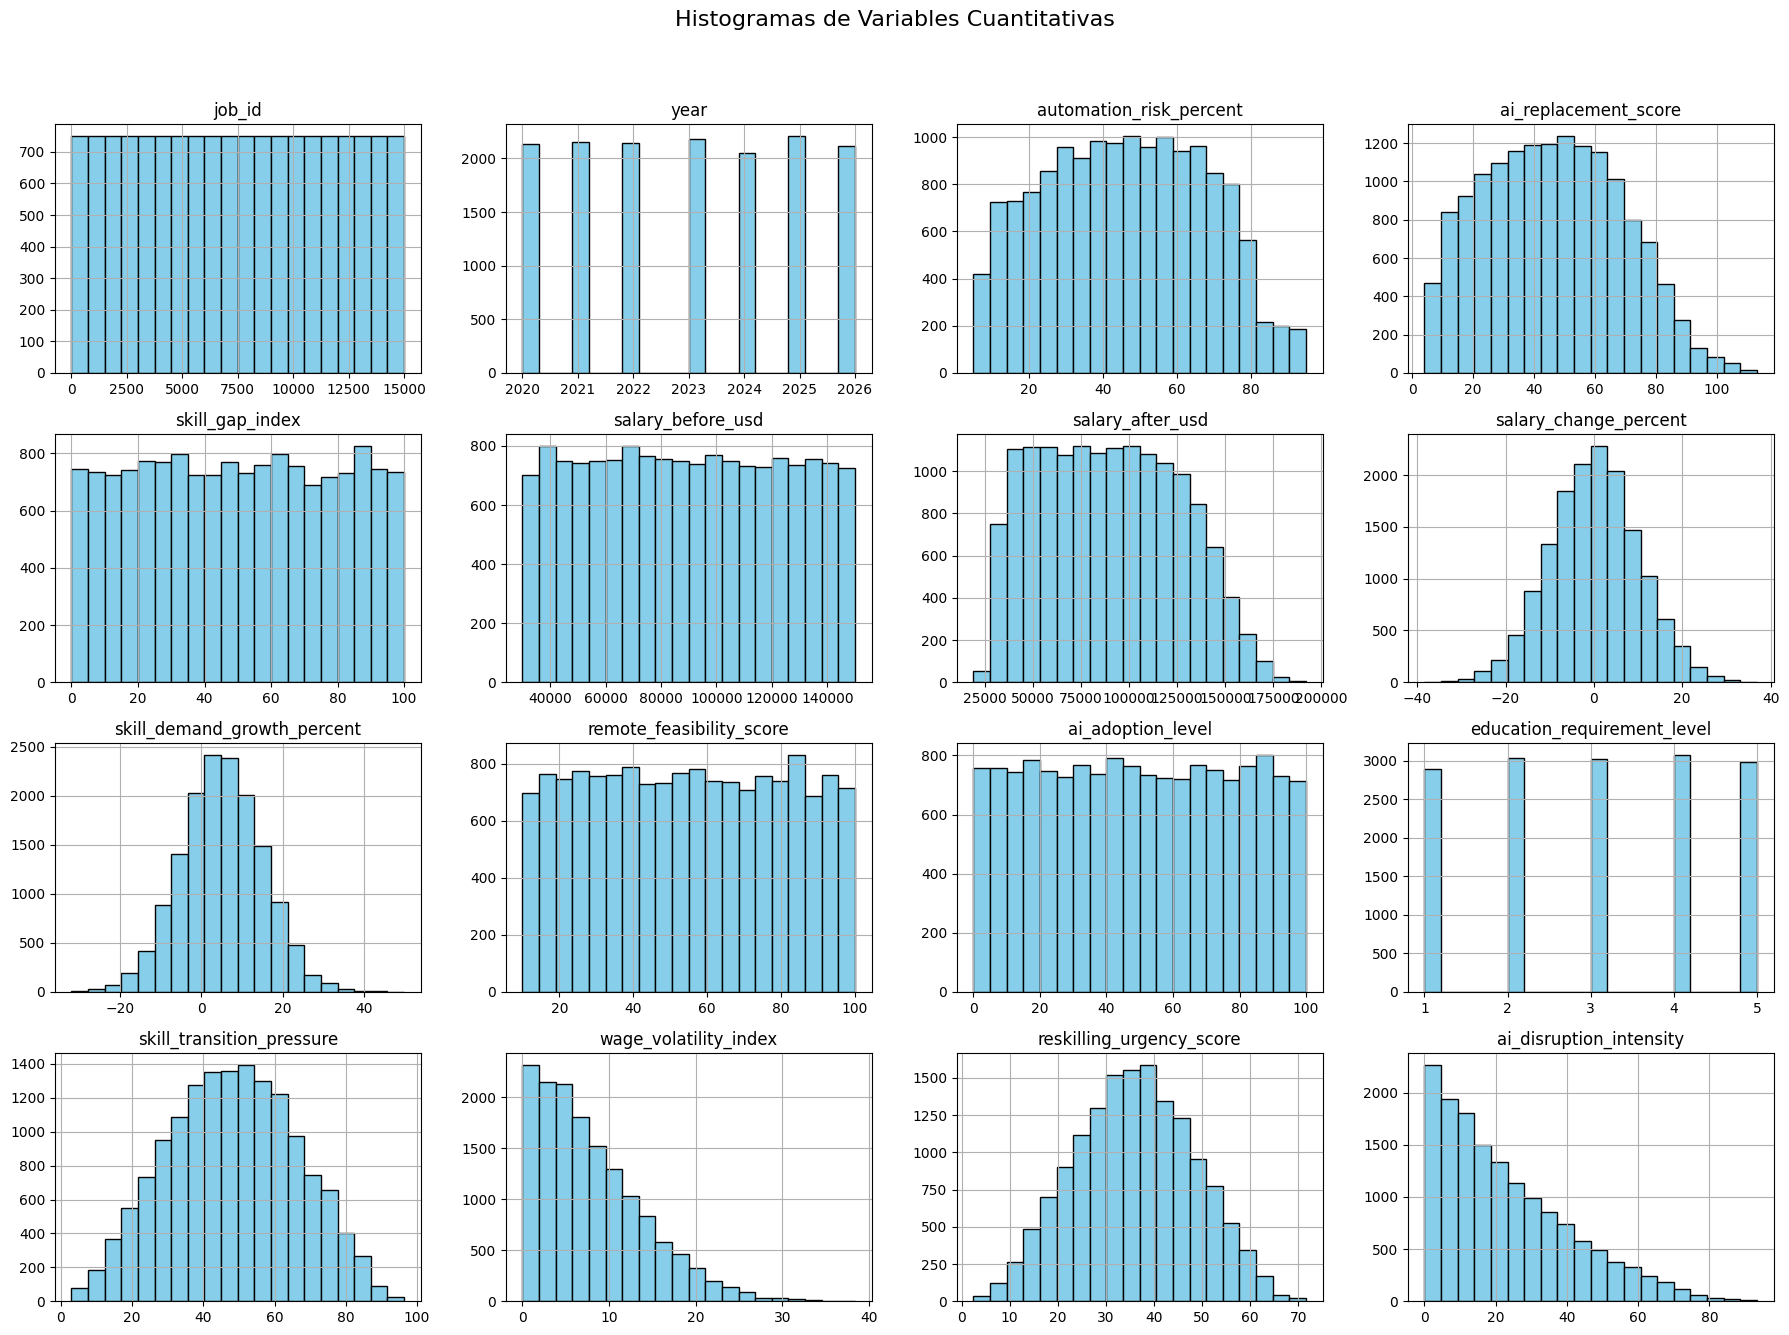

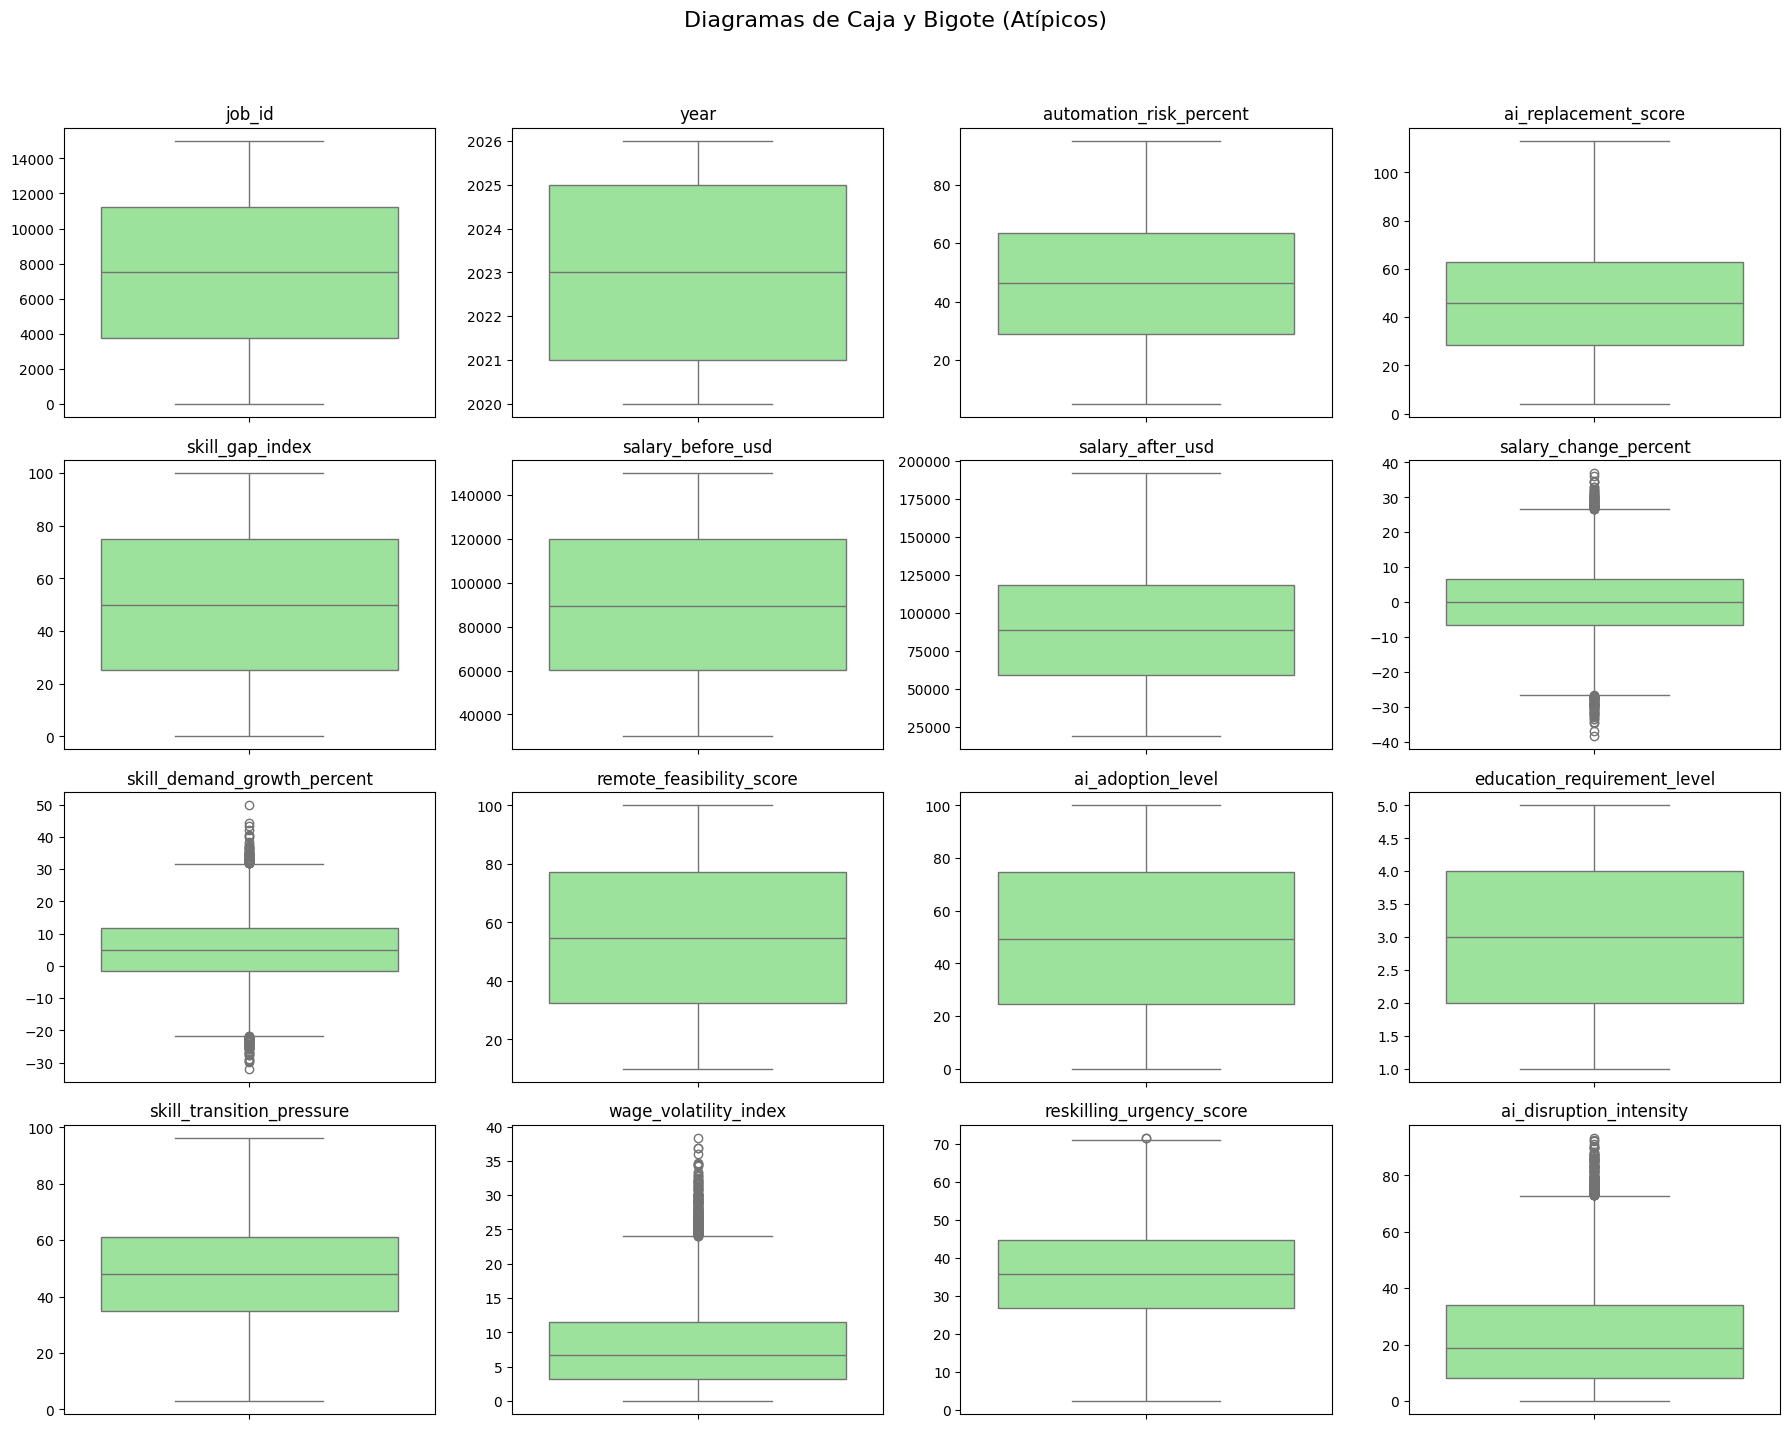


--- Comparativa: Media Muestral vs Media Recortada (10%) ---
Variable: skill_demand_growth_percent
   Media Muestral:      5.0205
   Media Recortada 10%: 5.0158
Variable: salary_change_percent
   Media Muestral:      0.1143
   Media Recortada 10%: 0.0780

--- Centrimedia (Recorte al 25%) ---
Centrimedia de wage_volatility_index: 6.9076
Centrimedia de ai_disruption_intensity: 19.4354


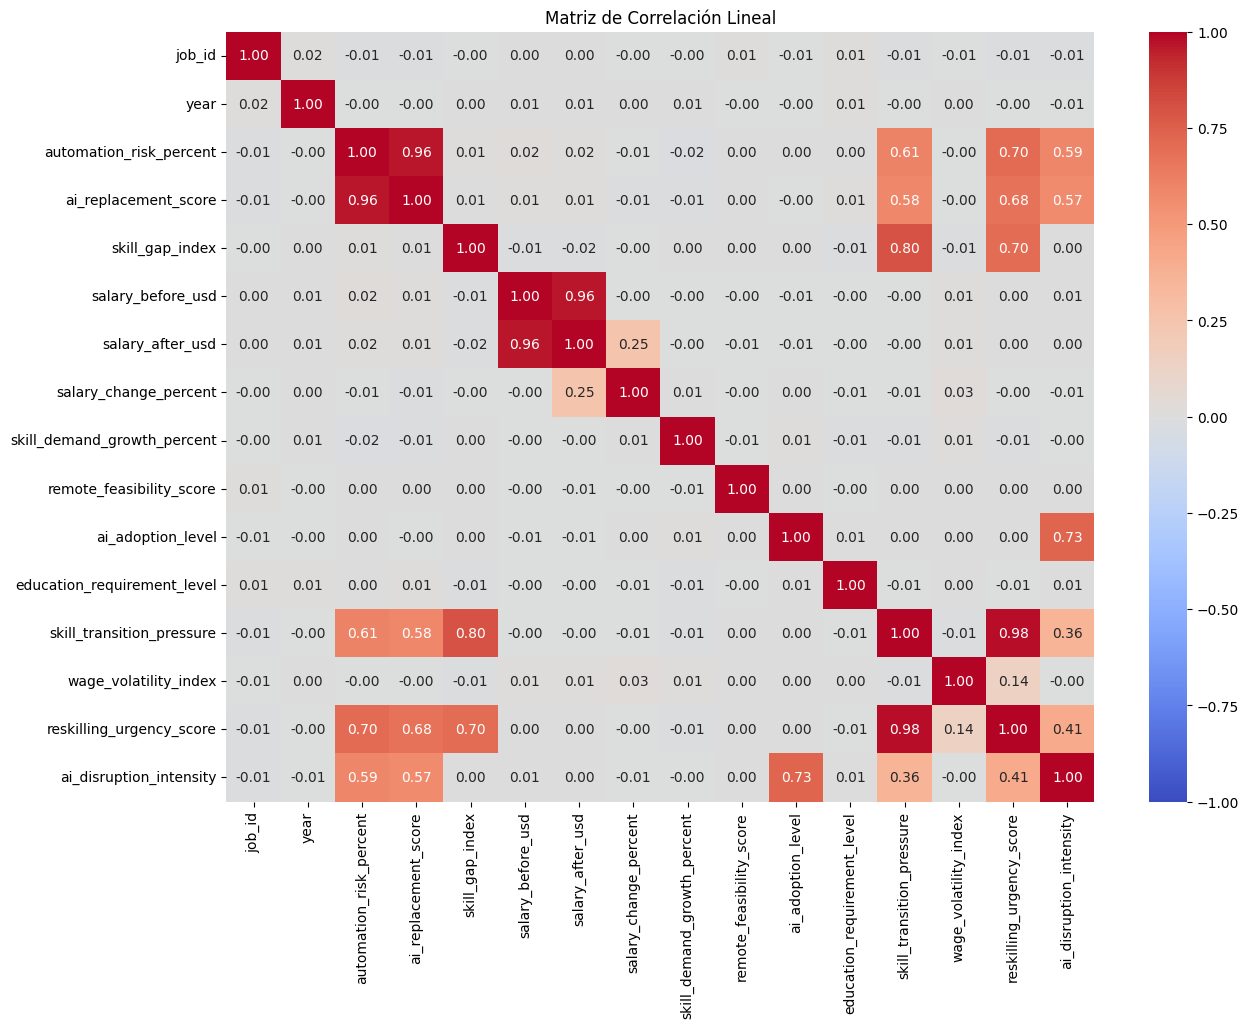


--- Pares con MAYOR correlación lineal ---
reskilling_urgency_score y skill_transition_pressure (r = 0.9794)
ai_replacement_score y automation_risk_percent (r = 0.9644)
salary_after_usd y salary_before_usd (r = 0.9629)

--- Pares NO correlacionados (cercanos a 0) ---
remote_feasibility_score y ai_replacement_score (r = 0.0002)
skill_gap_index y year (r = 0.0002)
wage_volatility_index y ai_adoption_level (r = 0.0001)


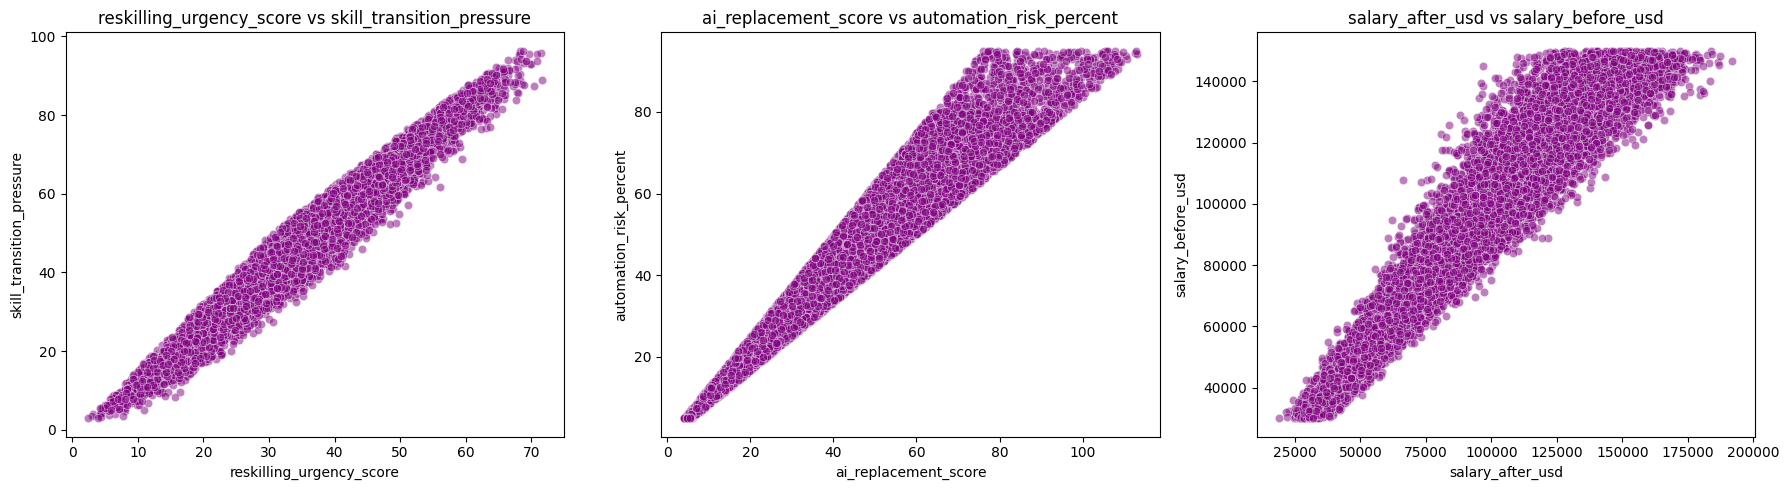


--- FACTORES QUE INCIDEN EN EL IMPACTO DE LA IA (ai_disruption_intensity) ---

1. Factores con influencia directa significativa:
   - ai_adoption_level (r = 0.7315)
   - automation_risk_percent (r = 0.5903)
   - ai_replacement_score (r = 0.5654)
   - reskilling_urgency_score (r = 0.4139)
   - skill_transition_pressure (r = 0.3557)
   Justificación: Estas variables presentan un coeficiente de correlación moderado a fuerte (alejado de 0). Matemáticamente, esto demuestra que a medida que estas métricas cambian (por ejemplo, el riesgo de automatización), la intensidad de la disrupción provocada por la IA se incrementa o disminuye de forma proporcional y predecible.

2. Factores sin influencia significativa:
   - education_requirement_level (r = 0.0070)
   - salary_before_usd (r = 0.0055)
   - salary_after_usd (r = 0.0041)
   - skill_gap_index (r = 0.0033)
   - remote_feasibility_score (r = 0.0019)
   - wage_volatility_index (r = -0.0023)
   - skill_demand_growth_percent (r = -0.0044)
   -

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('ai_job_replacement_2020_2026_v2.csv')

print("--- Primeras 10 observaciones ---")
print(df.head(10))

print("\n--- Últimas 12 observaciones ---")
print(df.tail(12))

print("\n--- Listado de variables involucradas ---")
print(df.columns.tolist())

print("\n--- Estadísticos de las variables (Cuantitativas) ---")
print(df.describe())

print("\n--- Frecuencias de cada categoría (Variables Categóricas) ---")
vars_categoricas = df.select_dtypes(include=['object']).columns
for col in vars_categoricas:
    print(f"\n> Variable: {col}")
    print(df[col].value_counts())

# Variables cuantitativas
vars_cuantitativas = df.select_dtypes(include=[np.number]).columns

# Histograma de variables cuantitativas
df[vars_cuantitativas].hist(figsize=(18, 14), bins=20, edgecolor='black', color='skyblue')
plt.suptitle("Histogramas de Variables Cuantitativas", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Diagramas de caja y bigote
fig, axes = plt.subplots(nrows=int(np.ceil(len(vars_cuantitativas)/4)), ncols=4, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(vars_cuantitativas):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col)
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Diagramas de Caja y Bigote (Atípicos)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Comparativa: Media Muestral vs Media Recortada (10%) ---")
vars_recorte = ['skill_demand_growth_percent', 'salary_change_percent']
for var in vars_recorte:
    media_muestral = df[var].mean()
    media_recortada = stats.trim_mean(df[var].dropna(), 0.10)
    print(f"Variable: {var}")
    print(f"   Media Muestral:      {media_muestral:.4f}")
    print(f"   Media Recortada 10%: {media_recortada:.4f}")

print("\n--- Centrimedia (Recorte al 25%) ---")
vars_centrimedia = ['wage_volatility_index', 'ai_disruption_intensity']
for var in vars_centrimedia:
    centrimedia = stats.trim_mean(df[var].dropna(), 0.25)
    print(f"Centrimedia de {var}: {centrimedia:.4f}")

# Matriz de correlación
matriz_corr = df[vars_cuantitativas].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de Correlación Lineal")
plt.show()

# Determinar mayores y menores correlaciones
matriz_corr_abs = matriz_corr.abs()
upper_tri = matriz_corr_abs.where(np.triu(np.ones(matriz_corr_abs.shape), k=1).astype(bool))
pares_ordenados = upper_tri.unstack().dropna().sort_values(ascending=False)

top_3_pares = pares_ordenados.head(3).index.tolist()
peores_pares = pares_ordenados.tail(3).index.tolist()

print("\n--- Pares con MAYOR correlación lineal ---")
for par in top_3_pares:
    print(f"{par[0]} y {par[1]} (r = {matriz_corr.loc[par[0], par[1]]:.4f})")

print("\n--- Pares NO correlacionados (cercanos a 0) ---")
for par in peores_pares:
    print(f"{par[0]} y {par[1]} (r = {matriz_corr.loc[par[0], par[1]]:.4f})")

# Gráficos de dispersión para los top 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, par in enumerate(top_3_pares):
    sns.scatterplot(data=df, x=par[0], y=par[1], ax=axes[i], alpha=0.5, color='purple')
    axes[i].set_title(f"{par[0]} vs {par[1]}")
plt.tight_layout()
plt.show()

# Factores que inciden en ai_disruption_intensity
print("\n--- FACTORES QUE INCIDEN EN EL IMPACTO DE LA IA (ai_disruption_intensity) ---")
corr_impacto = matriz_corr['ai_disruption_intensity'].drop('ai_disruption_intensity')

print("\n1. Factores con influencia directa significativa:")
factores_directos = corr_impacto[corr_impacto.abs() >= 0.3] 
for var, val in factores_directos.sort_values(ascending=False).items():
    print(f"   - {var} (r = {val:.4f})")
print("   Justificación: Estas variables presentan un coeficiente de correlación moderado a fuerte "
      "(alejado de 0). Matemáticamente, esto demuestra que a medida que estas métricas cambian "
      "(por ejemplo, el riesgo de automatización), la intensidad de la disrupción provocada por la IA "
      "se incrementa o disminuye de forma proporcional y predecible.")

print("\n2. Factores sin influencia significativa:")
factores_nulos = corr_impacto[corr_impacto.abs() < 0.1]
for var, val in factores_nulos.sort_values(ascending=False).items():
    print(f"   - {var} (r = {val:.4f})")
print("   Justificación: Estas variables presentan un coeficiente de correlación muy cercano a 0, "
      "lo que estadísticamente indica que no existe una relación lineal con la intensidad de la disrupción "
      "por IA. Variaciones en estos aspectos no alteran de forma evidente el impacto global del reemplazo laboral.")